In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [19]:
df = pd.read_csv('sdss_sample.csv')

In [20]:
features = ['u', 'g', 'r', 'i', 'z']
X = df[features]
y = df['redshift']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
linear = LinearRegression()

linear.fit(X_train, y_train)
y_pred = linear.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.2984839018189941
R2: 0.51534002408584


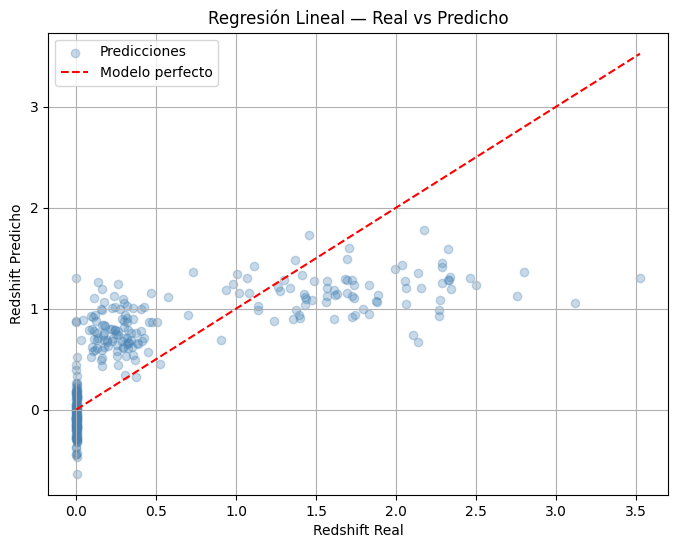

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', label='Predicciones')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Modelo perfecto')

plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Regresión Lineal — Real vs Predicho')
plt.legend()
plt.grid(True)
plt.show()